# Sri Lankan University Student Performance Analysis

This notebook documents exploratory data analysis for the assignment prototype. The dataset contains simulated university records and must not be presented as real student research data.

In [1]:
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Find the project root whether the notebook runs from the workspace or notebooks folder.
PROJECT_ROOT = next(
    (
        path for path in [Path.cwd(), *Path.cwd().parents]
        if (path / 'data' / 'raw' / 'sri_lankan_university.csv').exists()
        and (path / 'src').is_dir()
    ),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError(
        'Could not locate the project root containing data/raw and src.'
    )
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.sri_lankan_schema import categorize_gpa

DATA_PATH = PROJECT_ROOT / 'data' / 'raw' / 'sri_lankan_university.csv'
data = pd.read_csv(DATA_PATH)
data['performance_category'] = data['semester_gpa'].apply(categorize_gpa)
data.head()

,academic_year,semester,faculty,programme,previous_gpa,attendance_percentage,study_hours_per_week,failed_modules,assignment_completion_percentage,assessment_average_percentage,lecture_participation_percentage,tutorial_participation,lms_active,internet_access,financial_work_pressure,wellbeing_rating,semester_gpa,performance_category
0,4,2,Computing,Information Technology,3.19,87.6,6,0,58.4,86.3,78.8,yes,no,yes,no,3,2.31,Average
1,1,2,Management,Accounting,3.01,73.0,13,0,82.3,80.4,82.6,yes,yes,yes,yes,4,2.44,Average
2,3,2,Humanities,Social Sciences,2.11,76.0,9,0,92.0,75.0,60.9,yes,no,yes,no,4,1.96,At Risk
3,4,1,Management,Accounting,3.12,84.4,12,0,91.1,89.6,82.9,no,yes,yes,yes,2,3.07,High Performance
4,3,1,Management,Business Management,2.28,66.8,16,0,96.0,92.2,71.3,yes,yes,limited,no,2,2.46,Average


## 1. Data quality and structure

In [2]:
print(f'Records: {len(data)}')
print(f'Features before the target: {len(data.columns) - 2}')
print(f'Total missing values: {int(data.isna().sum().sum())}')
print('Duplicate rows:', int(data.duplicated().sum()))
data.dtypes

Records: 360
Features before the target: 16
Total missing values: 0
Duplicate rows: 0


academic_year                         int64
semester                              int64
faculty                                 str
programme                               str
previous_gpa                        float64
attendance_percentage               float64
study_hours_per_week                  int64
failed_modules                        int64
assignment_completion_percentage    float64
assessment_average_percentage       float64
lecture_participation_percentage    float64
tutorial_participation                  str
lms_active                              str
internet_access                         str
financial_work_pressure                 str
wellbeing_rating                      int64
semester_gpa                        float64
performance_category                    str
dtype: object

## 2. Target distribution

,records
performance_category,
At Risk,84
Average,221
High Performance,55


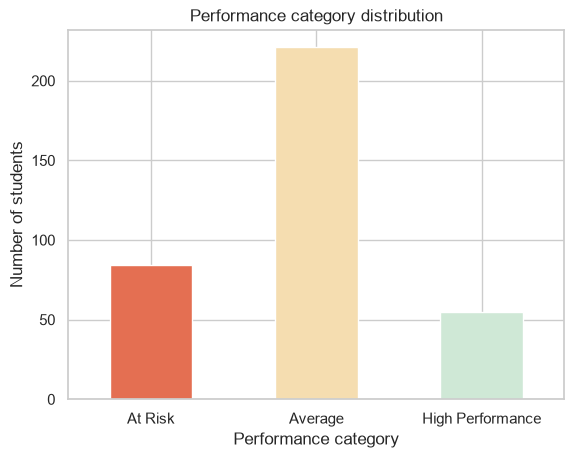

In [3]:
category_counts = data['performance_category'].value_counts().reindex(['At Risk', 'Average', 'High Performance'])
display(category_counts.to_frame('records'))
sns.set_theme(style='whitegrid')
category_counts.plot(kind='bar', color=['#e46f52', '#f5ddb0', '#cfe8d6'], title='Performance category distribution')
plt.ylabel('Number of students')
plt.xlabel('Performance category')
plt.xticks(rotation=0)
plt.show()

## 3. Relationships with academic performance

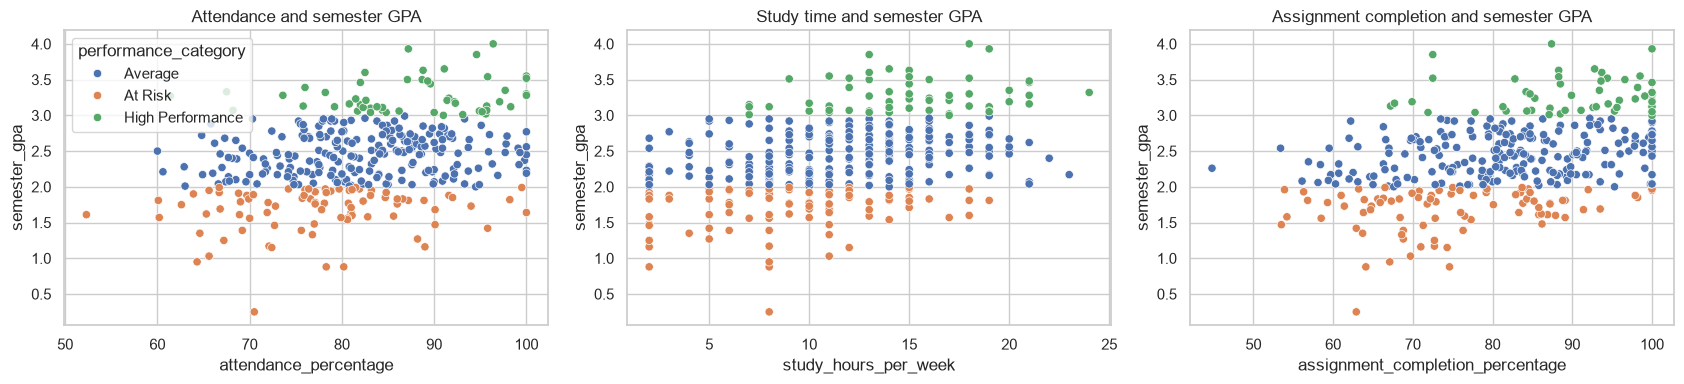

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4))
sns.scatterplot(data=data, x='attendance_percentage', y='semester_gpa', hue='performance_category', ax=axes[0])
axes[0].set_title('Attendance and semester GPA')
sns.scatterplot(data=data, x='study_hours_per_week', y='semester_gpa', hue='performance_category', ax=axes[1], legend=False)
axes[1].set_title('Study time and semester GPA')
sns.scatterplot(data=data, x='assignment_completion_percentage', y='semester_gpa', hue='performance_category', ax=axes[2], legend=False)
axes[2].set_title('Assignment completion and semester GPA')
plt.tight_layout()
plt.show()

,correlation_with_semester_gpa
semester_gpa,1.000000
previous_gpa,0.429093
assignment_completion_percentage,0.426792
study_hours_per_week,0.401345
assessment_average_percentage,0.378452
attendance_percentage,0.351207
lecture_participation_percentage,0.301630
semester,0.000246
academic_year,-0.003084
wellbeing_rating,-0.075932


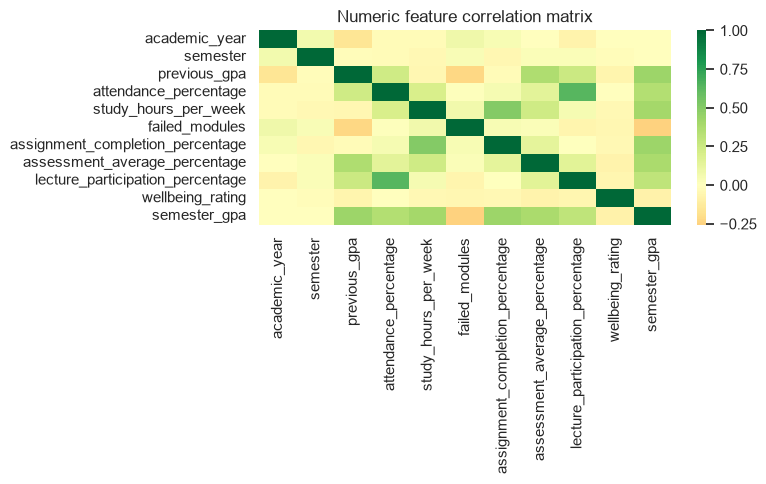

In [5]:
numeric_columns = data.select_dtypes(include='number').columns
correlations = data[numeric_columns].corr()['semester_gpa'].sort_values(ascending=False)
display(correlations.to_frame('correlation_with_semester_gpa'))
plt.figure(figsize=(8, 5))
sns.heatmap(data[numeric_columns].corr(), cmap='RdYlGn', center=0)
plt.title('Numeric feature correlation matrix')
plt.tight_layout()
plt.show()

## 4. Interpretation

The analysis checks whether attendance, study time, assignment completion, assessment results, and previous GPA show meaningful relationships with semester GPA. These relationships support the academic-focused feature choices, but correlation does not prove causation. The model must still be evaluated on held-out records.

In [6]:
# The first cell adds the project root to sys.path. This fallback keeps this cell
# usable when it is run independently after a kernel restart.
from pathlib import Path
import sys

if 'PROJECT_ROOT' not in globals():
    PROJECT_ROOT = next(
        (
            path for path in [Path.cwd(), *Path.cwd().parents]
            if (path / 'data' / 'raw' / 'sri_lankan_university.csv').exists()
            and (path / 'src').is_dir()
        ),
        None,
    )
    if PROJECT_ROOT is None:
        raise FileNotFoundError(
            'Could not locate the project root containing data/raw and src.'
        )
    sys.path.insert(0, str(PROJECT_ROOT))

from src.train_sri_lankan_model import train_model

model = train_model()
print('Selected model:', type(model.named_steps['model']).__name__)
print('Saved pipeline inputs:', list(model.feature_names_in_))

Selected model: RandomForestClassifier
Saved pipeline inputs: ['academic_year', 'semester', 'previous_gpa', 'attendance_percentage', 'study_hours_per_week', 'failed_modules', 'assignment_completion_percentage', 'assessment_average_percentage', 'lecture_participation_percentage', 'wellbeing_rating', 'faculty', 'programme', 'tutorial_participation', 'lms_active', 'internet_access', 'financial_work_pressure']


## 5. Final evaluation

Run the evaluation module after training to produce accuracy, precision, recall, and F1-score:

```bash
python -m src.evaluate_sri_lankan_model
```

The current results are a synthetic-data assignment baseline, not evidence of performance on real Sri Lankan students.